http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

##  Data Description 
*3 Models*: 
- Overall Churn
- Voluntary Churn
- Involuntary Churn

### Notes: 2016-September-Era Overall Churn Model
- Population (Base Line Definition):  Active Paid customers with at least 30 days of active period
- Event: Retention (1), Churn (0)
- Table: <schema>.<churn_table>
- Train/Val Split: 70%, 30%
- Test is performed on out-of-sample customers and out-of-sample-range dates.

Dimensionality Reduction (Training Only):

EXL first developed the Churn model, and did so taking the same steps as they did in their Retention Model.  In fact, in the early Churn Models, the event was still considered retention (1) and churn was considered a non-event (0).  In later models, this was changed such that churn is now the event (1).  

The customer summary tables are generally stored in Redshift Production as <schema>.<churn_table_mmddyy>.  The original full-featured table has &lt;mmddyy&gt;=072516.  The model under review used the customer summary table with &lt;mmddyy&gt;=080316.

| Step | Remaining Features | Notes |
|-----:|-------------------:|------:|
| Post-Cleanse | 682 | Following 2016-09-09 Excel File |
| Corr w/ Target | 61 | EXL keeps any _CORR(feature,target)_ $>=$ 0.07 |
| Information Value / Sub-IV | 61 | 2 strong, 57 medium, 2 week (kept all) |
| Clustering | 18 or 25 | Segmented variables into 12 clusters. <br> Highlight 25 candidates, but only show 18 in VIF section. |
| VIF | 18 | Remaining features listed below. |


The 18 leftover features were:

| | Var Name | | Var Name | | Var Name |
|--|--------|--|----------|--|---------|
| 1.|  num_strms_pl_tm_11_15_ring | 2.|  num_strms_pl_tm_6_10_all| 3.|  num_strms_pl_tm_gt60_ring| 
| 4.|  strm_tm_ring| 5.|  net_ppv_dur_all | 6.|  num_strms_pl_tm_gt60_net_ppv | 
| 7.|  num_pmts | 8.|  num_ppv_watched_all | 9.|  num_cm_em_rcvd_1st_60days | 
|10.|  num_strms_pl_tm_16_30_net_ppv | 11.|  vod_pl_tm_all | 12.|  num_cm_em_rcvd_all_tm |
|13.|  lin_num_shows_watched | 14.|  lin_dur | 15.|  overall_num_device_types | 
|16.|  num_strms_pl_tm_16_30_net_orig | 17.|  num_ordrs_gift | 18.|  num_vol_losses | 

All data is from the same table (<schema>.<churn_table>); inv/vol is a flag feature.

Table has 1,836,681 rows with 755 features.  Most of the features are obviously redundant or useless. 

### Notes: 2017-February-Era Overal Churn Model

The Churn Model evolved quite a bit from September to February.  The 1-Month Churn Model as of 2017-02-03 had only 7 variables:

1. num_vol_losses
2. pmt_pct_days_paid
3. pct_ppv1
4. num_invol_fail
5. no_view_90days_flag
6. vod_lst_30days
7. nxt_view_ep_lst_90days

The latest version of the customer summary table I could find was with &lt;mmddyy&gt;=102416.  Unfortunately, this table does not contain pmt_pct_days_paid, pct_ppv1, or nxt_view_ep_lst_90days.

The 57 dates (as_on_dt):

| Year | Month | Day |
|------|-------|-----|
| 2015 |  07   | 08, 16, 19, 20, 21, 31 |
|      |  08   | 15, 19, 23, 24, 25, 27 |
|      |  09   | 11, 20, 21, 22, 26, 30 |
|      |  10   | 08, 23, 25, 26, 27 |
|      |  11   | 07, 11, 19, 22, 23, 24 |
|      |  12   | 04, 13, 14, 15, 19, 23, 31 |
| 2016 |  01   | 15, 24, 25, 26, 30 |
|      |  02   | 03, 11, 21, 22, 23, 26 |
|      |  03   | 12, 16, 24 |
|      |  04   | 03, 04, 05, 08, 23 |
|      |  05   | 01, 02 |

Out-of-Time (OOT) Validation:  2016-01-01   (Is that really out of time?)
Out-of-Time (OOT) Validation:  2016-08-01   (At least this is actually out of time.)


## Load Necessary Tools
Vizualization References
[Pandas](http://pandas.pydata.org/pandas-docs/stable/visualization.html),
[Seaborn](https://seaborn.pydata.org/)

In [2]:
# Redshift Engine
from sqlalchemy import create_engine
from pandas import read_sql_query as qry
# Data Sci 
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import tensorflow as tf
# Viz
%matplotlib inline
from matplotlib import pyplot as plt
from pandas.tools.plotting import scatter_matrix

## Connect to Redshift

In [3]:
db='<database>'
host='<redshift-host>'
user='<username>'
psswd='<password>'
conStr='postgresql://'+user+':'+psswd+'@'+host+':5439/'+db
con = create_engine(conStr)

### Note
Some of the model variables were not available in the Redshift table (only in SAS data files).  The customer summary table was updated (<schema>.<churn_table>).

## Import Data

In [4]:
# Big4 Dates
rumble = ['2015-01-25','2016-01-24','2017-01-29']
slam = ['2015-08-23','2016-08-21','2017-08-20']
survivor = ['2015-11-22','2016-11-20','2017-11-19']
mania = ['2015-03-29','2016-04-03','2017-04-02']

# Query!
df = qry("SELECT \
              as_on_dt, \
              cust_guid, \
              num_vol_losses, \
              pmt_pct_days_paid, \
              pct_ppv1, \
              num_invol_fail, \
              CASE \
                WHEN no_view_90days_flag = 0 THEN -1 \
                ELSE no_view_90days_flag \
                END AS no_view_90days_flag, \
              vod_lst_30days, \
              nxt_view_ep_lst_90days, \
              CASE \
                WHEN (as_on_dt BETWEEN '"+rumble[0]+"'::date-'1 month'::interval \
                    AND '"+rumble[0]+"'::date) \
                    OR (as_on_dt BETWEEN '"+rumble[1]+"'::date-'1 month'::interval \
                    AND '"+rumble[1]+"'::date) \
                    OR (as_on_dt BETWEEN '"+rumble[2]+"'::date-'1 month'::interval \
                    AND '"+rumble[2]+"'::date) \
                  THEN 1 \
                  ELSE -1 \
                  END AS rumble30, \
              CASE  \
                WHEN (as_on_dt BETWEEN '"+slam[0]+"'::date-'1 month'::interval \
                    AND '"+slam[0]+"'::date) \
                    OR (as_on_dt BETWEEN '"+slam[1]+"'::date-'1 month'::interval \
                    AND '"+slam[1]+"'::date) \
                    OR (as_on_dt BETWEEN '"+slam[2]+"'::date-'1 month'::interval \
                    AND '"+slam[2]+"'::date) \
                  THEN 1 \
                  ELSE -1 \
                  END AS slam30, \
              CASE  \
                WHEN (as_on_dt BETWEEN '"+survivor[0]+"'::date-'1 month'::interval \
                    AND '"+survivor[0]+"'::date) \
                    OR (as_on_dt BETWEEN '"+survivor[1]+"'::date-'1 month'::interval \
                    AND '"+survivor[1]+"'::date) \
                    OR (as_on_dt BETWEEN '"+survivor[2]+"'::date-'1 month'::interval \
                    AND '"+survivor[2]+"'::date) \
                  THEN 1 \
                  ELSE -1 \
                  END AS survivor30, \
              CASE  \
                 WHEN (as_on_dt BETWEEN '"+mania[0]+"'::date-'1 month'::interval \
                    AND '"+mania[0]+"'::date) \
                    OR (as_on_dt BETWEEN '"+mania[1]+"'::date-'1 month'::interval \
                    AND '"+mania[1]+"'::date) \
                    OR (as_on_dt BETWEEN '"+mania[2]+"'::date-'1 month'::interval \
                    AND '"+mania[2]+"'::date) \
                  THEN 1 \
                  ELSE -1 \
                  END AS mania30, \
              CASE \
                WHEN ram_country = 'us' THEN 1 \
                ELSE -1 \
                END AS domestic, \
              CASE \
                WHEN pmt1_aftr_as_on  = 0 THEN 0 \
                WHEN pmt1_aftr_as_on >= 1 THEN 1 \
                ELSE NULL \
                END AS pay1 \
          FROM <schema>.<churn_table> \
            WHERE current_state='Active Paid' \
              AND latest_active_period > 29 \
              AND current_rc_payer = 0 \
              AND pmt1_aftr_as_on IS NOT NULL \
         ",con)

## Feature Size 
This is actually pretty small data: full data set is only ~71 MB

In [5]:
# Show Variable Sizes (~11 MB per feature)
print('Size of one feature column: ',np.array(df['num_vol_losses']).nbytes/1e6,' MB')
print('Size of total data set: ',np.array(df).nbytes/1e6)

Size of one feature column:  4.753616  MB
Size of total data set:  71.30424


## Data Viz and Exploration
Always good to make sure things look right!

In [210]:
x_cols = ['num_vol_losses','num_invol_fail',
            'vod_lst_30days','pmt_pct_days_paid','pct_ppv1',
            'nxt_view_ep_lst_90days','no_view_90days_flag','rumble30','mania30','slam30','survivor30']
xx_cols = ['num_vol_losses','num_invol_fail',
            'vod_lst_30days','pmt_pct_days_paid','pct_ppv1',
            'nxt_view_ep_lst_90days','no_view_90days_flag']
y_cols = ['pay1']

### DV1: Histograms

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x115a121d0>]], dtype=object)

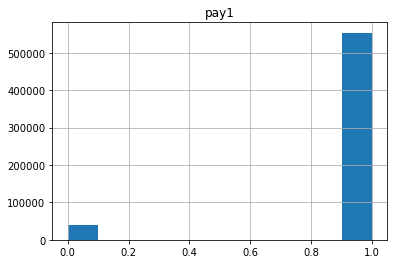

In [251]:
df[y_cols].hist()

num_vol_losses
NOTE: Might be a good idea in the future to use a 'nudged logarithm' 
      or sqrt of this variable.


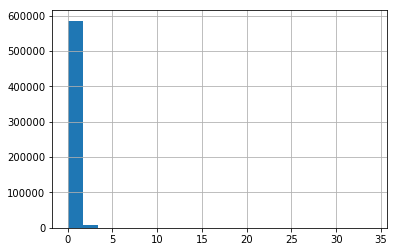

In [285]:
print(x_cols[0])
print("NOTE: Might be a good idea in the future to use a 'nudged logarithm' \n      or sqrt of this variable.")
df[x_cols[0]].hist(bins=20)

num_invol_fail


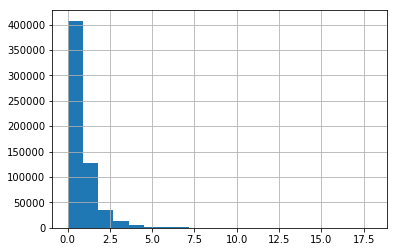

In [286]:
print(x_cols[1])
df[x_cols[1]].hist(bins=20)

### DV2:  Scatter Plots
Note:  Each individual scatter plot takes 5-10 seconds to compute, so a scatter plot matrix that looks at each pairing of 8 vars takes quite a while!  Avoid running and re-running for your own sanity.  (Actually, it takes so long that I had to interrupt the kernel.  This is something that needs to be run overnight, or we have to settle for picking and choosing only several scatterplots...)

In [9]:
#print(x_cols[1],' vs ',x_cols[0])
#scatter_matrix(df)

## Data Cleanse:  Fill the NaNs in num_invol_fail

In [10]:
df=df.fillna(0)

## Data Shape

In [364]:
# Input Features Matrix
#  -- make into np.array and explicitly set data type
#  -- ordinals, conts, flags
#
#  x_cols for oldvars+newvars 
# xx_cols for just oldvars
#
x_data = np.array( df[x_cols], dtype=np.float32)

# Input Labels ("Input Outputs") Matrix
#  -- make into np.array and explicitly set data type
y_data = np.array(df[y_cols], dtype=np.float32)

# Extra Info
extra_info = df[['as_on_dt','cust_guid','domestic']]

# Shape
n_data     = x_data.shape[0]
n_features = x_data.shape[1]
n_classes  = y_data.shape[1]

## Training, Validation, and Test Splits

In [365]:
from sklearn.model_selection import train_test_split
x_train, x_vt, y_train, y_vt = train_test_split(x_data, y_data, test_size=0.5, random_state=42)
x_valid, x_test, y_valid, y_test = train_test_split(x_vt, y_vt, test_size=0.5, random_state=31)

print('Training:    (n_instances, n_features) = ',x_train.shape)
print('Validation:  (n_instances, n_features) = ',x_valid.shape)
print('Test:        (n_instances, n_features) = ',x_test.shape)

Training:    (n_instances, n_features) =  (297101, 11)
Validation:  (n_instances, n_features) =  (148550, 11)
Test:        (n_instances, n_features) =  (148551, 11)


## Feature Normalization

----------------

[Advice from CS231n](http://cs231n.github.io/neural-networks-2/) <br/>
Common pitfall. An important point to make about the preprocessing is that any preprocessing statistics (e.g. the data mean) must only be computed on the training data, and then applied to the validation / test data. E.g. computing the mean and subtracting it from every image across the entire dataset and then splitting the data into train/val/test splits would be a mistake. Instead, the mean must be computed only over the training data and then subtracted equally from all splits (train/val/test).

----------------

This is an essential step for successful utilization of neural networks (and most machine learning methods in general). There are many way to normalize, and some normalizations are inappropriate for some types of variables.  

For a neural network, at the very least one should apply a "location subtraction" and "scale division" to any continuous or ordinal variables. A typical "location subtraction" is by the mean: var = var - mean(var).  A typical "scale division" is by the standard deviation: var = var/std(var).  I call it z-scoring when you do both: 

```{python}
def zscore(vec):
    # vec should be 1D np.array or pd.DataFrame
    return (vec - vec.mean())/vec.std()
```
<br/>

Sometimes the location subtraction is by the minimum and the scale division by the range:

```{python}
def fscore(vec):
    # vec should be 1D np.array or pd.DataFrame
    return (vec - vec.min())/(vec.max()-vec.min())
```
<br/>

But in neural networks, it is often important to try to zero-center each feature as much as possible, so a variation on this would be better:

```{python}
def fnscore(vec):
    # vec should be 1D np.array or pd.DataFrame
    mn = vec.min()
    mx = vec.max()
    return (2*vec - (mx+mn))/(mx-mn)
```
<br/>

| Feature Type | Model Inputs |
|--------------|--------------|
|**Binary**    | no_view_90days_flag, rumble30, slam30, survivor30, mania30          |
|**Ordinal**| num_vol_losses, num_invol_fail                                         |
|**Continuous**| pmt_pct_days_paid, pct_ppv1, vod_lst_30days, nxt_view_ep_lst_90days |


Quick Notes: A categorical variable An ordinal variable is a categoriable variable with an associated ordering. An evenly-spaced ordinal variable is often referred to as an interval variable. 


<br/>

| Ordinal Vars    |                            Ordinates                         |
|-----------------|--------------------------------------------------------------|
| num_vol_losses  | 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 23, 34             |
| num_invol_fail  | 0, 1, 2, 3, 4, 5, 7, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18 |

#### Tips and Tricks
Apparently:

* One gets better results by using {-1,1} instead of {0,1}, e.g., as recommended [here](https://visualstudiomagazine.com/articles/2013/07/01/neural-network-data-normalization-and-encoding.aspx); I already implemented this in Redshift query.
* 0.5\*z(Var) makes continuous variables better comparable to binaries.
* We can treat the ordinal vars like continuous vars.  

http://www.faqs.org/faqs/ai-faq/neural-nets/part2/

#### Notes
1. <p>**Logarithms**: I will only normalize the features as is for better comparison with the prior SAS model.  That said, in the future, I think some of these variables should be logged, some made categorial, and some both. For example:
<p>lvod = np.log(df['vod_lst_30days']+1e-1) <br/>
nvod = (lvod-lvod.mean())/(2*lvod.std())
<p>lpp = np.log(df['pmt_pct_days_paid']) <br/>
npp = (lpp-lpp.mean())/(2*lpp.std()) <br/>
npp.hist()
</center>

2. <p>**Informed Discretization**:  I think pct_ppv1 clearly can benefit from the retention/churn analyses I've done (samplers, plateau, completers).  
<br/>

## Additional Cleansing
See section on PCA whitening:  http://cs231n.github.io/neural-networks-2/

### Whoa there!
I assumed the NXT variable was a boolean flag, so was not normalizing it.  No matter what I did to my model, the AUC stayed at 0.5.  It was frustrating.  As I explored difference pieces of code, I realized two things.  The first observation was that the half-z normalization was not strong enough to normalize the variables that are predominately zero, but infrequently range out to 1, 2, 3, and so on.  To remedy this, I applied the [-1,1]-scoring feature normalization function outlined above... But still, AUC=0.5.  So I checked my arrays maxima again... 113? WTF?  Turned out that the NXT variable had gigantic values.  Once normalized, my AUC began to change here and there, so yay.  But an interesting observation is that despite my AUC going  up a bit, my "shot calling accuracy" went down.  That's...odd...?


In [366]:
# Half-Z Normalization
def halfz(xtrain, xval, xtest):
    # vec can be np.array or pd.DataFrame
    mmm = xtrain.mean()
    sss = xtrain.std()
    return {'loc': mmm, 'scale': sss,
      'train': 0.5*(xtrain - mmm)/sss,
      'val': 0.5*(xval - mmm)/sss,
      'test': 0.5*(xtest - mmm)/sss}

def fnn(xtrain,xval,xtest):
    # vec should be 1D np.array or pd.DataFrame
    mn = xtrain.min()
    mx = xtrain.max()
    return {'mn':mn, 'mx':mx,
            'train': (2*xtrain - (mx+mn))/(mx-mn),
            'val':   (2*xval   - (mx+mn))/(mx-mn),
            'test':  (2*xtest  - (mx+mn))/(mx-mn)}
            

# Proceed w/ Feature Normalization
nvl    = fnn(x_train[:,0],x_val[:,0],x_test[:,0])
nif    = fnn(x_train[:,1],x_val[:,1],x_test[:,1])
vod    = fnn(x_train[:,2],x_val[:,2],x_test[:,2])
ppd    = fnn(x_train[:,3],x_val[:,3],x_test[:,3])
ppv    = fnn(x_train[:,4],x_val[:,4],x_test[:,4])
nxt    = fnn(x_train[:,5],x_val[:,5],x_test[:,5])

x_train[:,0],x_val[:,0],x_test[:,0] = nvl['train'], nvl['val'], nvl['test']
x_train[:,1],x_val[:,1],x_test[:,1] = nif['train'], nif['val'], nif['test']
x_train[:,2],x_val[:,2],x_test[:,2] = vod['train'], vod['val'], vod['test']
x_train[:,3],x_val[:,3],x_test[:,3] = ppd['train'], ppd['val'], ppd['test']
x_train[:,4],x_val[:,4],x_test[:,4] = ppv['train'], ppv['val'], ppv['test']
x_train[:,5],x_val[:,5],x_test[:,5] = ppv['train'], ppv['val'], ppv['test']

## Check Point
The data has been extracted from Redshift, split 50-25-25 into the train-validate-test subsets, and properly transformed and normalized to take full advantage of machine learning algorithms. It is now time to construct the logistic regression architecture in TensorFlow's neural network representation.

#### WTF?!?!?!
Might I have a class imbalance problem?!
https://aqibsaeed.github.io/2016-08-10-logistic-regression-tf/

#### Some Helpful TF Pages
http://learningtensorflow.com/index.html

In [367]:
### EXPERIMENTATION w/ SimpLogReg
# Col2: vod last 30 days
x_temp = np.array([x_train[:,2]]).transpose()
x_tempval = np.array([x_valid[:,2]]).transpose()
x_temp.shape

(297101, 1)

In [368]:
#-----------------------------------------------------
# Session Parameters
#-----------------------------------------------------
learning_rate = 0.1
epochs = 10
batch_size=128
display_step = 1


# Just in case...
tf.reset_default_graph()

#-----------------------------------------------------
# Input Data Placeholders
#-----------------------------------------------------
#  -- None: 
#     [None, n_features] and [None, n_classes] denotes that
#     we are not specifying how many instances will be used
#     for any given training session or data batch.
####
## need to set x_feed to (None,n_features) after experimentation
#x_feed = tf.placeholder(shape=(None,1), dtype=tf.float32)
x_feed = tf.placeholder(shape=(None,n_features), dtype=tf.float32, name="x_feed")
y_feed = tf.placeholder(shape=(None,n_classes), dtype=tf.float32, name="y_feed")


#-----------------------------------------------------
# Initialize Parameters
#-----------------------------------------------------
#   -- y = x*W + b
#   -- if x is (n_instances x 8), then W should be (8x1) 
#        s.t. xW is (n_instances x 1)
#   -- initialization of weights:  randomNum / sqrt(n_features)
####
# need to set w to (n_features,n_classes) after experimentation!!!
w = tf.Variable(
    tf.truncated_normal(
        #(1,n_classes),
        (n_features,n_classes),
        mean=0,
        stddev=np.sqrt(2.0/n_features),
        dtype=tf.float32,
        seed=2),
    name="weight")
b = tf.Variable(
    tf.zeros(
        n_classes,
        dtype=tf.float32),
    name="bias")


#-----------------------------------------------------
# Construct model
#-----------------------------------------------------
#  -- to construct a simple logistic regression, 
#     construct a simple linear regression and  
#     compute its sigmoid
#  -- to construct a multiple logistic regression,
#     construct a multiple linear regression and
#     compute its softmax
#
#  Note: SimpLogReg->tf.multiply, MultLogReg->tf.matmul
#
linReg = tf.add(tf.matmul(x_feed, w), b)
#y_model = tf.nn.sigmoid(linReg)
y_model = tf.nn.sigmoid(linReg)


#-----------------------------------------------------
# Choose a Learning Method:  Loss Fcn & Optimizer
#-----------------------------------------------------
# Optimizers: tf.train.
#               AdamOptimizer, GradientDescentOptimizer
loss = tf.reduce_mean(tf.square(y_model - y_feed), name="loss")
optimizer = tf.train.AdamOptimizer(learning_rate, name="opt")
train = optimizer.minimize(loss)


# Other Optmization/Loss Options (future exploration)
# Cross Entropy w/ Gradient Descent
# If I bin all my numerical data, I can use classification techniques...
#cost_ce = tf.reduce_mean(-tf.reduce_sum(y*tf.log(py), reduction_indices=1))
#cost_ce = tf.reduce_mean(-tf.reduce_sum(y*tf.log(py)))
#cost_ce = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(py,y),reduction_indices=1)
#opt_gd_ce = tf.train.GradientDescentOptimizer(learning_rate).minimize(cost_ce)
#loss = tf.nn.l2_loss(py - y, name="l2_cost")
# Adam
#opt_adam_ce = tf.train.AdamOptimizer(learning_rate).minimize(cost_ce)
#opt_adam_l2 = tf.train.AdamOptimizer(learning_rate).minimize(cost_l2)

## Execute TensorFlow Session

In [369]:
#-----------------------------------------------------
# Initialize TF Variables
#-----------------------------------------------------
init = tf.global_variables_initializer()

#-----------------------------------------------------
# Open TF Session
#-----------------------------------------------------
sess = tf.Session()

#-----------------------------------------------------
# Graph Execution / Training
#-----------------------------------------------------
sess.run(init)
param_updates = []
#param_updates = np.empty(shape=[1],dtype=float)
for i in range(epochs):
    avg_loss = 0.0
    total_batch = int(x_train.shape[0]/batch_size)
    
    for j in range(total_batch):
        bx = x_train[i*batch_size:(i+1)*batch_size]
        # simpLogReg->x_temp, multLogReg->x_train
        #evals = sess.run([train,w,b,loss], feed_dict={y_feed: y_train, x_feed: x_temp})[1:]
        evals = sess.run([train, w, b, loss], feed_dict={y_feed: y_train, x_feed: x_train})[1:]
        avg_loss += evals[2]/total_batch
    
    if i % display_step == 0:
        #_w = evals[0][0,0]  # for simpLogReg
        _w = evals[0][0,0]  # for multLogReg
        _b = evals[1][0]
        _l = evals[2]
        print('Epoch: ','%04d' % i, '  Weight: ',
              '{:.9f}'.format(_w),'  Bias: ','{:.9f}'.format(_b))
        print('    EndLoss: ', '{:.9f}'.format(_l),'  AvgLoss: ', 
              '{:.9f}'.format(avg_loss))
        print(' ')
        param_updates.append(evals)

print('Training Complete!')
wf=_w
bf=_b
print('Final Parameters: ')
print('    w: ',wf)
print('    b: ',bf)

#-----------------------------------------------------
# How good did we do?
#-----------------------------------------------------
# !!! Change x_temp -> x_train after experimentation !!!!!!!!!!!
##y_pred = sess.run(y_model, feed_dict = {x_feed: x_tempval})
y_pred  = sess.run(y_model, feed_dict = {x_feed: x_valid})
y_class = np.array(y_pred > 0.5,dtype=np.float32)



Epoch:  0000   Weight:  -5.090208530   Bias:  2.895156145
    EndLoss:  0.058696244   AvgLoss:  0.058883334
 
Epoch:  0001   Weight:  -5.090583801   Bias:  2.916797161
    EndLoss:  0.058696400   AvgLoss:  0.058700464
 
Epoch:  0002   Weight:  -5.092379093   Bias:  2.918444395
    EndLoss:  0.058699053   AvgLoss:  0.058700585
 
Epoch:  0003   Weight:  -5.094012737   Bias:  2.920008659
    EndLoss:  0.058708303   AvgLoss:  0.058700636
 
Epoch:  0004   Weight:  -5.083103180   Bias:  2.910769463
    EndLoss:  0.058710918   AvgLoss:  0.058700486
 
Epoch:  0005   Weight:  -5.090541840   Bias:  2.916695356
    EndLoss:  0.058696434   AvgLoss:  0.058700633
 
Epoch:  0006   Weight:  -5.089397907   Bias:  2.914839983
    EndLoss:  0.058697354   AvgLoss:  0.058700626
 
Epoch:  0007   Weight:  -5.087521076   Bias:  2.913648605
    EndLoss:  0.058699924   AvgLoss:  0.058700560
 
Epoch:  0008   Weight:  -5.096296787   Bias:  2.922894478
    EndLoss:  0.058716875   AvgLoss:  0.058700594
 
Epoch:  00

In [370]:
#-----------------------------------------------------
# Close TF Session
#-----------------------------------------------------
sess.close()

#### Shot-Calling Accuracy 
93.21%, 93.18%, and 93.16% of the y_train, y_valid, and y_test data sets, respectively, represent those who made a payment in the next month.  So it should come as no surprise that "shot calling" is easy, e.g., you can get 93% accuracy just guessing a payment was made next month for every customer.  

With this in mind, it is unclear then if 94% accuracy is anything to brag about, or how much better is 95% accuracy than 94% accuracy?

In [371]:
#df['nxt_view_ep_lst_90days']

In [372]:
print('Customers who paid next month: ','{:.2f}'.format((100*sum(y_train)/y_train.shape[0])[0]),'% of the training set')
print('Shot Calling Accuracy','{:.2f}'.format(100*(sum(y_valid == y_class)/y_valid.shape[0])[0]))

Customers who paid next month:  93.21 % of the training set
Shot Calling Accuracy 93.21


In [381]:
fpr, tpr, threshold = roc_curve(y_valid, y_class, pos_label=1)
auc = roc_auc_score(y_valid, y_pred)
print('AUC: ', auc) 

AUC:  0.633476079741


In [380]:
help(roc_curve)

Help on function roc_curve in module sklearn.metrics.ranking:

roc_curve(y_true, y_score, pos_label=None, sample_weight=None, drop_intermediate=True)
    Compute Receiver operating characteristic (ROC)
    
    Note: this implementation is restricted to the binary classification task.
    
    Read more in the :ref:`User Guide <roc_metrics>`.
    
    Parameters
    ----------
    
    y_true : array, shape = [n_samples]
        True binary labels in range {0, 1} or {-1, 1}.  If labels are not
        binary, pos_label should be explicitly given.
    
    y_score : array, shape = [n_samples]
        Target scores, can either be probability estimates of the positive
        class, confidence values, or non-thresholded measure of decisions
        (as returned by "decision_function" on some classifiers).
    
    pos_label : int or str, default=None
        Label considered as positive and others are considered negative.
    
    sample_weight : array-like of shape = [n_samples], optiona

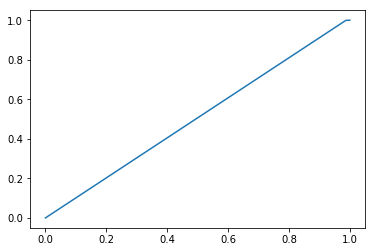

In [382]:
plt.plot(fpr, tpr)

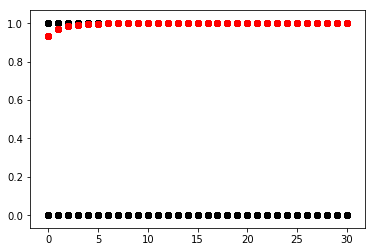

In [51]:
plt.scatter(x_tempval,y_valid,color='black')
plt.scatter(x_tempval,y_pred,color='red')

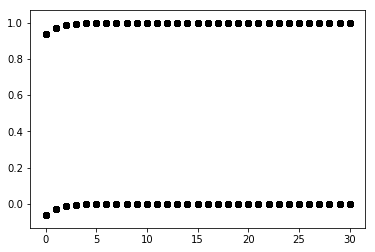

In [53]:
plt.scatter(x_tempval,y_pred-y_valid,color='black')

In [32]:
y_feed.shape

TensorShape([Dimension(None), Dimension(1)])

===================================================
# OLD CODE
## Do Not Run
===================================================

In [ ]:

#######################################################
# OLD CODE
######################################################


#-----------------------------------------------------
# Graph Execution
#-----------------------------------------------------
param_updates = np.empty(shape=[1],dtype=float)
with tf.Session() as sess:
    sess.run(init)

    #-------------------------------------------------
    # TRAINING 
    #-------------------------------------------------
    # Cycle over Epochs
    for epoch in range(epochs):
        avg_cost = 0.
        total_batch = int(x_train.shape[0]/batch_size)
        
        # Cycle over Batches
        for i in range(total_batch):
            # Get Batch
            bx_train = np.array(x_train[i*batch_size:(i+1)*batch_size], dtype='float32')
            by_train = np.array(y_train[i*batch_size:(i+1)*batch_size], dtype='float32')

            # Fit to Batch
            sess.run(train, feed_dict={x: bx_train, y: by_train})
            #sess.run(opt_gd_ce, feed_dict={x: batch_xs, y: batch_ys})
            
            # Record the Cost
            ccc = sess.run(loss, feed_dict={x: bx_train, y: by_train})

            # Compute average loss
            avg_cost += ccc / total_batch
        # endFor: Batches #########
        param_updates = np.append(param_updates, avg_cost)

        # Display logs per epoch step
        if (epoch+1) % display_step == 0:
            print("Epoch:", '%04d' % (epoch+1), "cost=", "{:.9f}".format(avg_cost))
    # endFor: Epochs ##########
    
    print("Optimization Finished!")

    #-------------------------------------------------
    # Test model
    #-------------------------------------------------
    # tf.argmax:  https://www.tensorflow.org/api_docs/python/tf/argmax
    #   --  Returns the index with the largest value across axes of a tensor.
    # argmax(py, 1) gives model's most likely label
    # argmax(y, 1) is the actual label
    py = sess.run(py , feed_dict = {x: x_test})
    correct_prediction = tf.equal(tf.argmax(py, 1), tf.argmax(y, 1))
    accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
    #print("Accuracy:", accuracy.eval({x: x_valid[:10000], y: y_valid[:10000]}))
    print("Accuracy:", sess.run(accuracy, feed_dict = {x: x_valid[:10000], y: y_valid[:10000]}))